# Supply Chain & Logística Inteligente com IA

## Segmentação de Clientes Logísticos e Detecção de Anomalias Operacionais

**Autor:** Fábio Andrade  
**Disciplina:** Supply Chain & Logística Inteligente com IA  
**Tipo:** Projeto final acadêmico  
**Ambiente de execução:** Google Colab  
**Repositório:** [supply-chain-clustering-anomaly-ai](https://github.com/thedrads/supply-chain-clustering-anomaly-ai)

### Linha escolhida

**Identificação de Clusters e Detecção de Anomalia**

### Objetivo do projeto

Aplicar técnicas de análise de dados e machine learning para segmentar clientes logísticos, identificar comportamentos fora do padrão e gerar insights gerenciais sobre custo logístico, nível de serviço, risco operacional e priorização de clientes.

## Preparação do ambiente

**Objetivo:** importar as bibliotecas necessárias para análise dos dados, visualização, clusterização e detecção de anomalias.

Essas ferramentas serão utilizadas durante todo o pipeline analítico do projeto.

In [4]:
# Importa bibliotecas para manipulação de dados.
import numpy as np
import pandas as pd

# Importa bibliotecas para visualização.
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Importa recursos para clusterização e detecção de anomalias.
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Configura a apresentação das tabelas e dos gráficos.
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")

# Define a semente para permitir resultados reproduzíveis.
random_state = 42

## Carregamento da base de dados

**Objetivo:** carregar a base sintética de clientes logísticos diretamente do GitHub.

A leitura pela URL pública torna o notebook reproduzível e elimina a necessidade de Google Drive ou upload manual.

In [5]:
# Define a localização pública da base sintética no GitHub.
dataset_url = (
    "https://raw.githubusercontent.com/thedrads/"
    "supply-chain-clustering-anomaly-ai/main/data/synthetic/"
    "clientes_logisticos_sinteticos_supply_chain.csv"
)

# Carrega os dados diretamente para um DataFrame.
clientes_df = pd.read_csv(dataset_url)

# Confirma as dimensões da base carregada.
print(
    f"Base carregada: {clientes_df.shape[0]} linhas e "
    f"{clientes_df.shape[1]} colunas."
)

Base carregada: 6000 linhas e 23 colunas.


## Visão inicial da base

**Objetivo:** visualizar os primeiros registros para conferir a estrutura, as colunas e os valores da base carregada.

In [6]:
# Exibe os cinco primeiros registros da base.
clientes_df.head()

,cliente_id,regiao,segmento_negocio,canal_relacionamento,porte_cliente,distancia_cd_km,volume_medio_entregue_kg,entregas_mes,ticket_medio_rs,receita_mensal_estimada_rs,lead_time_medio_dias,entregas_no_prazo_pct,custo_medio_entrega_rs,custo_logistico_mensal_rs,custo_por_kg_rs,taxa_ocorrencias_pct,variabilidade_demanda_pct,pedidos_urgentes_pct,prioridade_contrato,risco_operacional_score,anomalia_sintetica,tipo_anomalia_sintetica,cluster_teorico_sintetico
0,CLI_00001,Sul,Varejo,Marketplace,Pequeno,105.50,81.60,4,"2,328.61","9,314.42",3.47,99.11,325.95,"1,303.80",3.99,11.89,50.13,38.27,Baixa,27.32,0,normal,Baixo volume instável
1,CLI_00002,Sudeste,Indústria,Distribuidor,Grande,134.60,584.80,10,"4,243.14","42,431.38",2.83,97.21,280.25,"2,802.50",0.48,5.87,25.38,22.12,Média,18.20,0,normal,Recorrentes padrão
2,CLI_00003,Sudeste,Varejo,Venda direta,Grande,130.90,281.80,7,"1,838.57","12,870.01",3.46,87.31,280.49,"1,963.43",1.00,6.14,49.63,58.62,Baixa,32.70,0,normal,Baixo volume instável
3,CLI_00004,Nordeste,E-commerce,Distribuidor,Pequeno,379.30,917.80,7,"5,833.62","40,835.36",4.88,84.35,707.91,"4,955.37",0.77,6.01,22.65,25.58,Média,31.94,0,normal,Longa distância alto custo
4,CLI_00005,Sudeste,Varejo,B2B,Pequeno,61.10,"1,539.20",19,"10,152.08","192,889.60",1.36,95.39,209.20,"3,974.80",0.14,0.69,7.35,10.15,Alta,8.75,0,normal,Estratégicos urbanos


## Estrutura e tipos dos dados

**Objetivo:** examinar a estrutura do DataFrame, os tipos das variáveis e a quantidade de valores preenchidos em cada coluna.

In [7]:
# Apresenta a estrutura, os tipos e o preenchimento das colunas.
clientes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cliente_id                  6000 non-null   object 
 1   regiao                      6000 non-null   object 
 2   segmento_negocio            6000 non-null   object 
 3   canal_relacionamento        6000 non-null   object 
 4   porte_cliente               6000 non-null   object 
 5   distancia_cd_km             6000 non-null   float64
 6   volume_medio_entregue_kg    6000 non-null   float64
 7   entregas_mes                6000 non-null   int64  
 8   ticket_medio_rs             6000 non-null   float64
 9   receita_mensal_estimada_rs  6000 non-null   float64
 10  lead_time_medio_dias        6000 non-null   float64
 11  entregas_no_prazo_pct       6000 non-null   float64
 12  custo_medio_entrega_rs      6000 non-null   float64
 13  custo_logistico_mensal_rs   6000 

## Verificação de integridade

**Objetivo:** verificar valores ausentes, linhas duplicadas e identificadores de clientes repetidos.

Essa validação evita que problemas de qualidade comprometam as análises e os modelos posteriores.

In [8]:
# Conta todos os valores ausentes da base.
total_valores_ausentes = clientes_df.isna().sum().sum()

# Verifica linhas e identificadores duplicados.
total_linhas_duplicadas = clientes_df.duplicated().sum()
total_ids_duplicados = clientes_df["cliente_id"].duplicated().sum()

# Apresenta o resumo da verificação.
print(f"Valores ausentes: {total_valores_ausentes}")
print(f"Linhas duplicadas: {total_linhas_duplicadas}")
print(f"IDs de cliente duplicados: {total_ids_duplicados}")

Valores ausentes: 0
Linhas duplicadas: 0
IDs de cliente duplicados: 0


## Análise exploratória dos dados

### Estatísticas descritivas

**Objetivo:** analisar medidas de posição, dispersão e amplitude das variáveis numéricas operacionais.

A coluna de auditoria `anomalia_sintetica` será excluída desta análise para evitar influência prematura na interpretação.

In [9]:
# Seleciona variáveis numéricas e exclui a coluna de auditoria.
colunas_numericas_eda = (
    clientes_df.select_dtypes(include="number")
    .columns.drop("anomalia_sintetica")
)

# Calcula as principais estatísticas descritivas.
estatisticas_descritivas = (
    clientes_df[colunas_numericas_eda]
    .describe()
    .T
    .round(2)
)

# Exibe o resumo estatístico.
estatisticas_descritivas

,count,mean,std,min,25%,50%,75%,max
distancia_cd_km,"6,000.00",155.79,129.76,5.00,59.70,108.70,220.72,"1,131.14"
volume_medio_entregue_kg,"6,000.00",745.44,432.62,30.00,425.88,683.95,971.25,"2,285.30"
entregas_mes,"6,000.00",10.06,5.62,1.00,6.00,9.00,13.00,32.00
ticket_medio_rs,"6,000.00","5,010.15","2,808.58",250.00,"3,085.52","4,541.07","6,345.54","15,492.16"
receita_mensal_estimada_rs,"6,000.00","61,718.67","63,309.04",500.00,"19,402.21","39,205.98","69,774.60","328,081.95"
lead_time_medio_dias,"6,000.00",3.14,1.69,0.50,1.90,2.67,4.03,21.26
entregas_no_prazo_pct,"6,000.00",87.64,9.84,35.24,83.80,89.93,94.53,99.50
custo_medio_entrega_rs,"6,000.00",370.83,221.81,60.00,222.32,282.48,483.04,"2,914.27"
custo_logistico_mensal_rs,"6,000.00","3,283.12","2,014.09",147.15,"1,896.07","2,997.62","4,282.34","30,012.86"
custo_por_kg_rs,"6,000.00",0.86,1.49,0.06,0.27,0.53,1.01,63.58


### Leitura inicial das estatísticas

- A distância e a receita mensal apresentam médias superiores às medianas, indicando distribuições assimétricas e clientes com valores elevados.
- O custo por quilograma possui mediana de R$ 0,53 e máximo de R$ 63,58, sinalizando operações extremas que deverão ser investigadas.
- O lead time máximo de 21,26 dias e a pontualidade mínima de 35,24% indicam possíveis situações críticas de nível de serviço.
- A variabilidade da demanda, os pedidos urgentes e o risco operacional alcançam valores elevados em parte da base, sugerindo maior pressão logística nesses clientes.

Esses resultados são sinais exploratórios e ainda não confirmam anomalias ou relações de causa e efeito.

### Distribuição das variáveis categóricas

**Objetivo:** analisar a quantidade e a participação percentual dos clientes em cada categoria operacional.

As colunas sintéticas de auditoria não serão utilizadas nesta etapa exploratória.

In [10]:
# Define as variáveis categóricas operacionais.
colunas_categoricas_eda = [
    "regiao",
    "segmento_negocio",
    "canal_relacionamento",
    "porte_cliente",
    "prioridade_contrato",
]

# Prepara os resumos de quantidade e participação percentual.
resumos_categoricos = []

for coluna in colunas_categoricas_eda:
    contagem = clientes_df[coluna].value_counts()

    resumo_coluna = pd.DataFrame(
        {
            "variavel": coluna,
            "categoria": contagem.index,
            "quantidade": contagem.values,
            "percentual": (
                contagem.values / len(clientes_df) * 100
            ).round(2),
        }
    )

    resumos_categoricos.append(resumo_coluna)

# Consolida os resultados em uma única tabela.
distribuicao_categoricas = pd.concat(
    resumos_categoricos,
    ignore_index=True,
)

distribuicao_categoricas

,variavel,categoria,quantidade,percentual
0,regiao,Sudeste,2241,37.35
1,regiao,Sul,1193,19.88
2,regiao,Nordeste,1112,18.53
3,regiao,Centro-Oeste,782,13.03
4,regiao,Norte,672,11.20
5,segmento_negocio,Varejo,1920,32.00
6,segmento_negocio,Atacado,1309,21.82
7,segmento_negocio,Indústria,1086,18.10
8,segmento_negocio,E-commerce,1073,17.88
9,segmento_negocio,Serviços,612,10.20


### Leitura das variáveis categóricas

- A região Sudeste concentra 37,35% dos clientes, enquanto a região Norte representa 11,20%. Essa diferença deve ser considerada nas comparações regionais.
- O Varejo é o segmento mais frequente, com 32,00% da base, seguido pelo Atacado, com 21,82%.
- O canal B2B possui a maior participação, representando 42,28% dos relacionamentos.
- Clientes pequenos e médios correspondem, juntos, a 82,28% do portfólio analisado.
- Contratos de prioridade média, alta ou premium representam aproximadamente 84,11% da base.

Como a base é sintética, essa composição representa um cenário acadêmico e não a distribuição de uma empresa ou mercado real.

### Distribuição das principais variáveis numéricas

**Objetivo:** visualizar o formato das distribuições de indicadores econômicos, operacionais, de serviço e de risco.

Os histogramas ajudam a identificar assimetrias e possíveis valores extremos, mas não confirmam anomalias isoladamente.

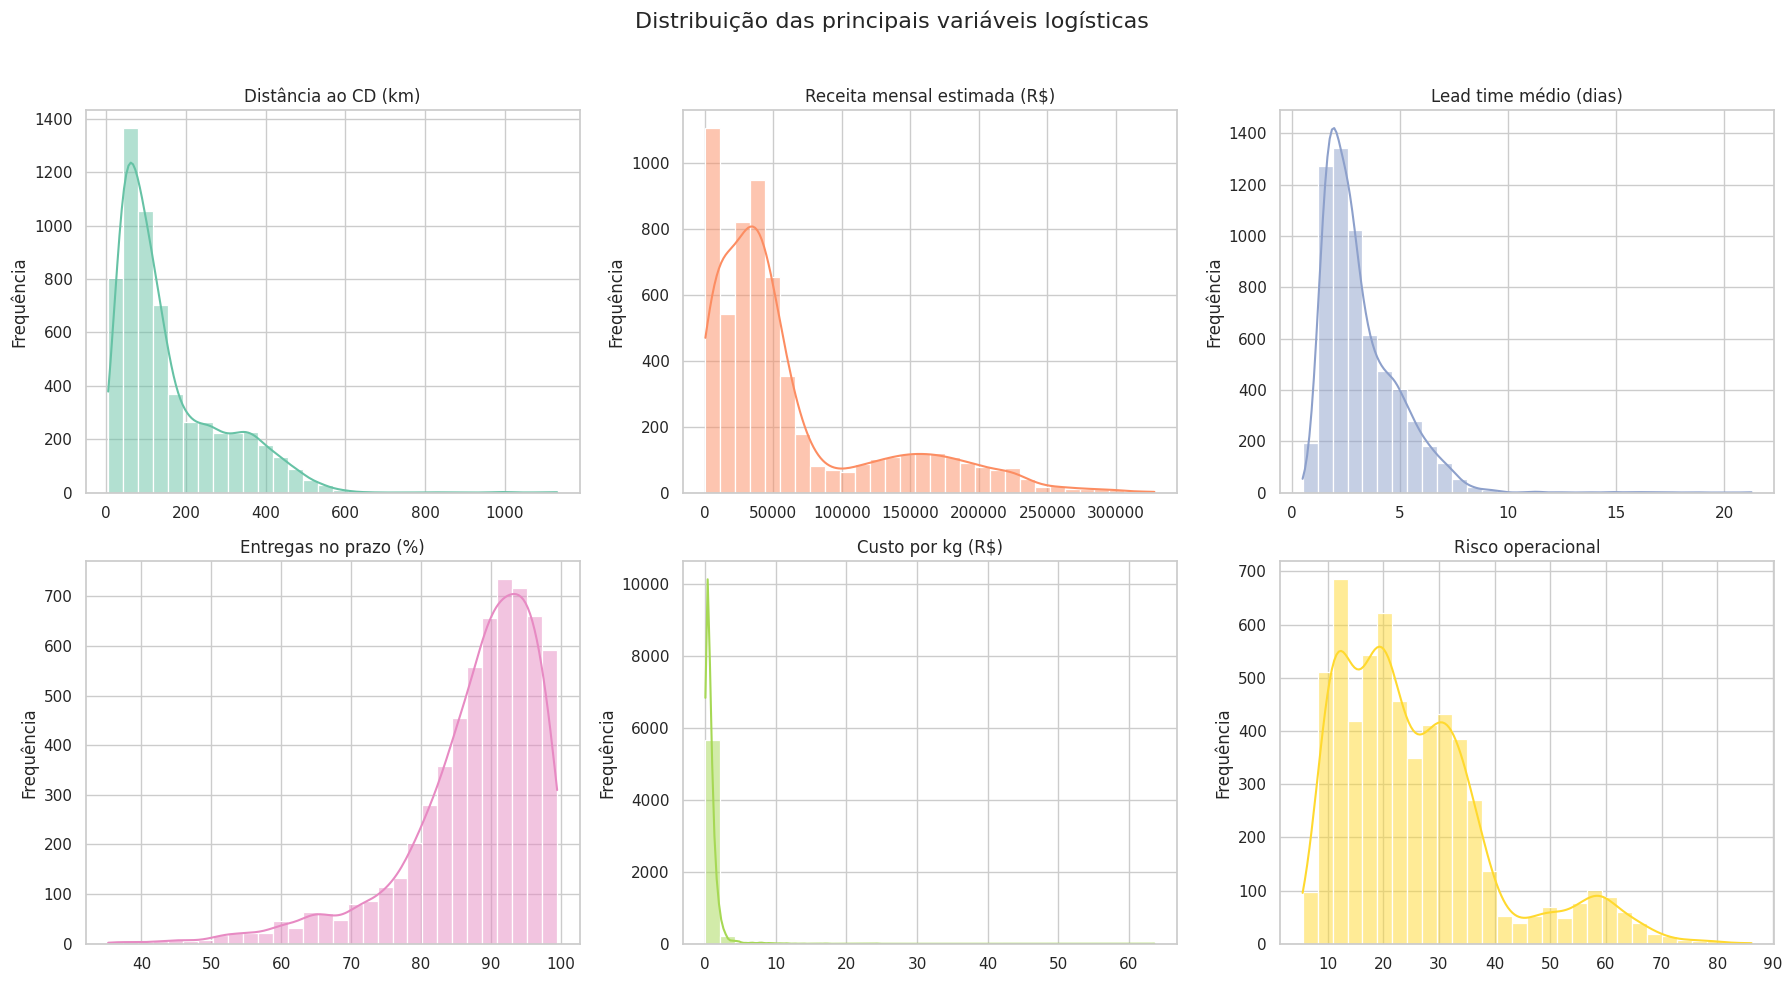

In [11]:
# Define as variáveis e os títulos dos gráficos.
variaveis_distribuicao = {
    "distancia_cd_km": "Distância ao CD (km)",
    "receita_mensal_estimada_rs": "Receita mensal estimada (R$)",
    "lead_time_medio_dias": "Lead time médio (dias)",
    "entregas_no_prazo_pct": "Entregas no prazo (%)",
    "custo_por_kg_rs": "Custo por kg (R$)",
    "risco_operacional_score": "Risco operacional",
}

# Cria a grade de histogramas.
fig, eixos = plt.subplots(2, 3, figsize=(18, 10))
cores = sns.color_palette("Set2", n_colors=6)

for eixo, (coluna, titulo), cor in zip(
    eixos.flat,
    variaveis_distribuicao.items(),
    cores,
):
    sns.histplot(
        data=clientes_df,
        x=coluna,
        bins=30,
        kde=True,
        color=cor,
        ax=eixo,
    )
    eixo.set_title(titulo)
    eixo.set_xlabel("")
    eixo.set_ylabel("Frequência")

# Ajusta o título e o espaçamento da figura.
fig.suptitle(
    "Distribuição das principais variáveis logísticas",
    fontsize=16,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Leitura das distribuições

- A distância ao centro de distribuição apresenta assimetria à direita: a maior parte dos clientes está em distâncias menores, mas existe uma cauda com operações acima de 600 km.
- A receita mensal mostra grupos com diferentes faixas econômicas, reforçando a possibilidade de segmentação dos clientes.
- O lead time concentra-se principalmente entre 1 e 5 dias, com poucos casos muito elevados. A pontualidade apresenta comportamento inverso, concentrando-se em níveis altos, mas com uma cauda de baixo desempenho.
- O custo por quilograma possui forte assimetria e poucos valores muito distantes do padrão, tornando-se uma variável importante para a detecção de anomalias.
- O risco operacional apresenta diferentes concentrações e um grupo menor de clientes com risco elevado, indicando potencial para segmentação e priorização gerencial.

Os padrões observados justificam o uso posterior de padronização, clusterização e métodos específicos de detecção de anomalias.

### Boxplots dos indicadores logísticos

**Objetivo:** visualizar a amplitude, os quartis e os possíveis valores extremos dos principais indicadores operacionais.

Os pontos além dos limites dos boxplots representam casos para investigação, mas não devem ser classificados automaticamente como anomalias.

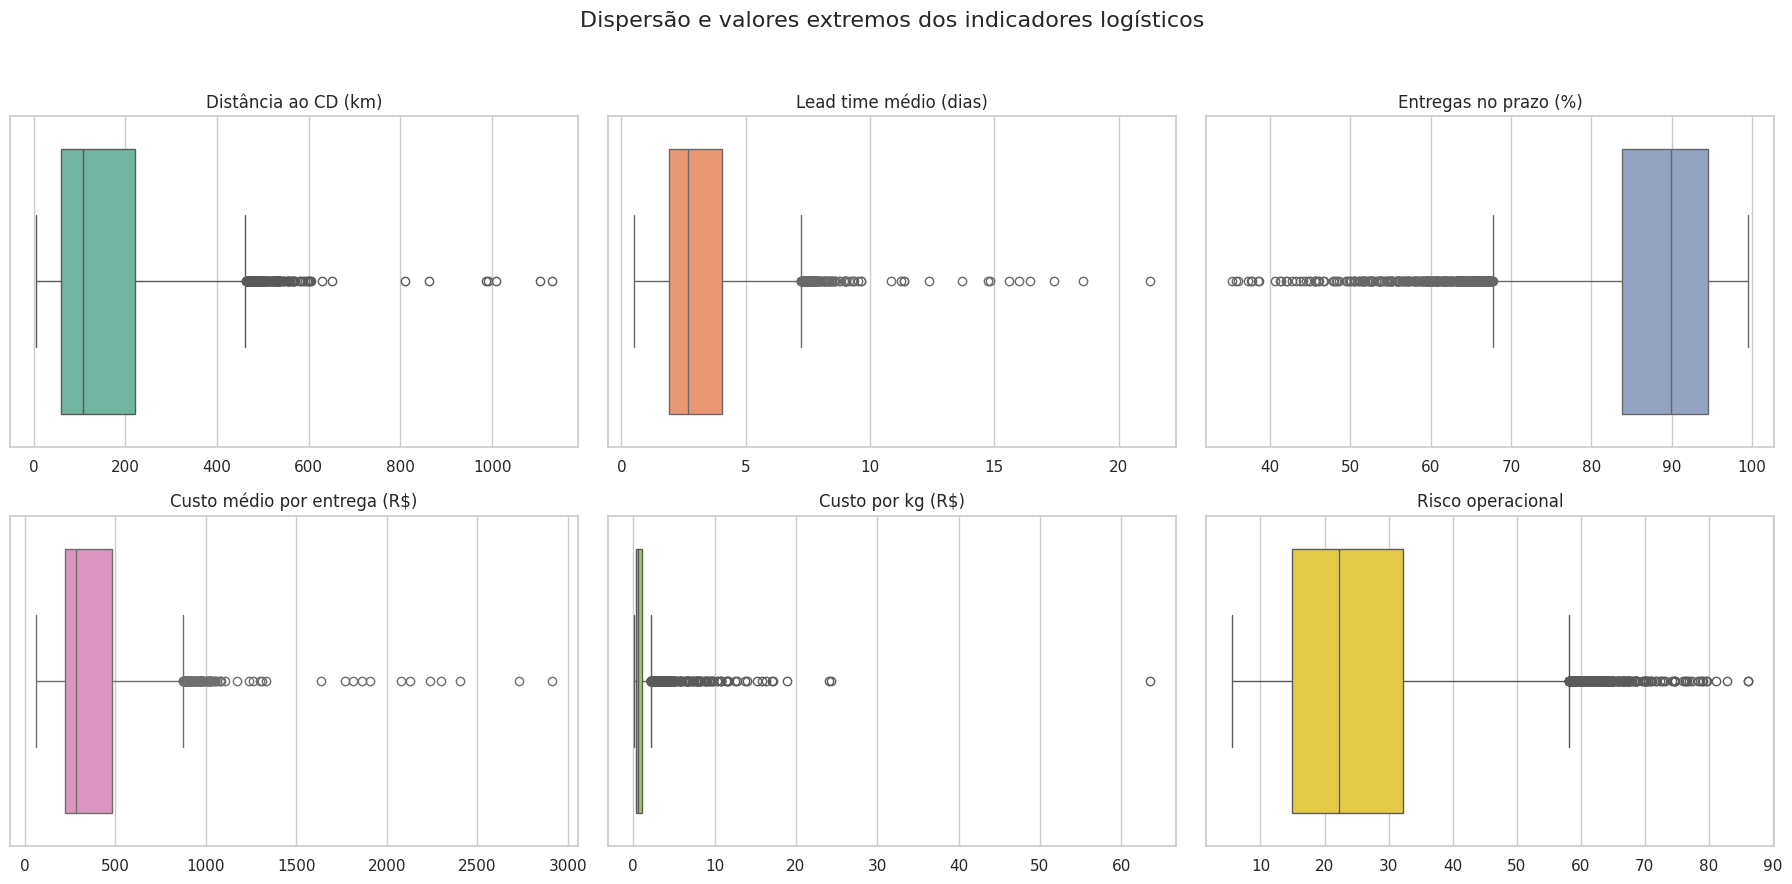

In [12]:
# Define as variáveis e os títulos dos boxplots.
variaveis_boxplot = {
    "distancia_cd_km": "Distância ao CD (km)",
    "lead_time_medio_dias": "Lead time médio (dias)",
    "entregas_no_prazo_pct": "Entregas no prazo (%)",
    "custo_medio_entrega_rs": "Custo médio por entrega (R$)",
    "custo_por_kg_rs": "Custo por kg (R$)",
    "risco_operacional_score": "Risco operacional",
}

# Cria a grade de boxplots.
fig, eixos = plt.subplots(2, 3, figsize=(18, 9))
cores = sns.color_palette("Set2", n_colors=6)

for eixo, (coluna, titulo), cor in zip(
    eixos.flat,
    variaveis_boxplot.items(),
    cores,
):
    sns.boxplot(
        data=clientes_df,
        x=coluna,
        color=cor,
        ax=eixo,
    )
    eixo.set_title(titulo)
    eixo.set_xlabel("")

# Ajusta o título e o espaçamento da figura.
fig.suptitle(
    "Dispersão e valores extremos dos indicadores logísticos",
    fontsize=16,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Leitura dos boxplots

- Distância e custo médio por entrega apresentam diversos valores acima do padrão, possivelmente associados a rotas mais longas ou operações mais complexas.
- Lead times elevados e percentuais reduzidos de entregas no prazo sinalizam clientes com possível pressão sobre o nível de serviço.
- O custo por quilograma apresenta a maior concentração de valores extremos, incluindo casos muito distantes da faixa predominante.
- O risco operacional possui um grupo de clientes acima da faixa usual, que poderá demandar priorização gerencial.

Os valores extremos serão preservados nesta fase, pois podem representar comportamentos logísticos legítimos ou anomalias relevantes. A classificação será realizada posteriormente por regras explicáveis e pelo Isolation Forest.

### Matriz de correlação

**Objetivo:** avaliar a intensidade e a direção das relações lineares entre as variáveis numéricas operacionais.

A correlação ajuda a compreender os dados, mas não demonstra causalidade entre os indicadores.

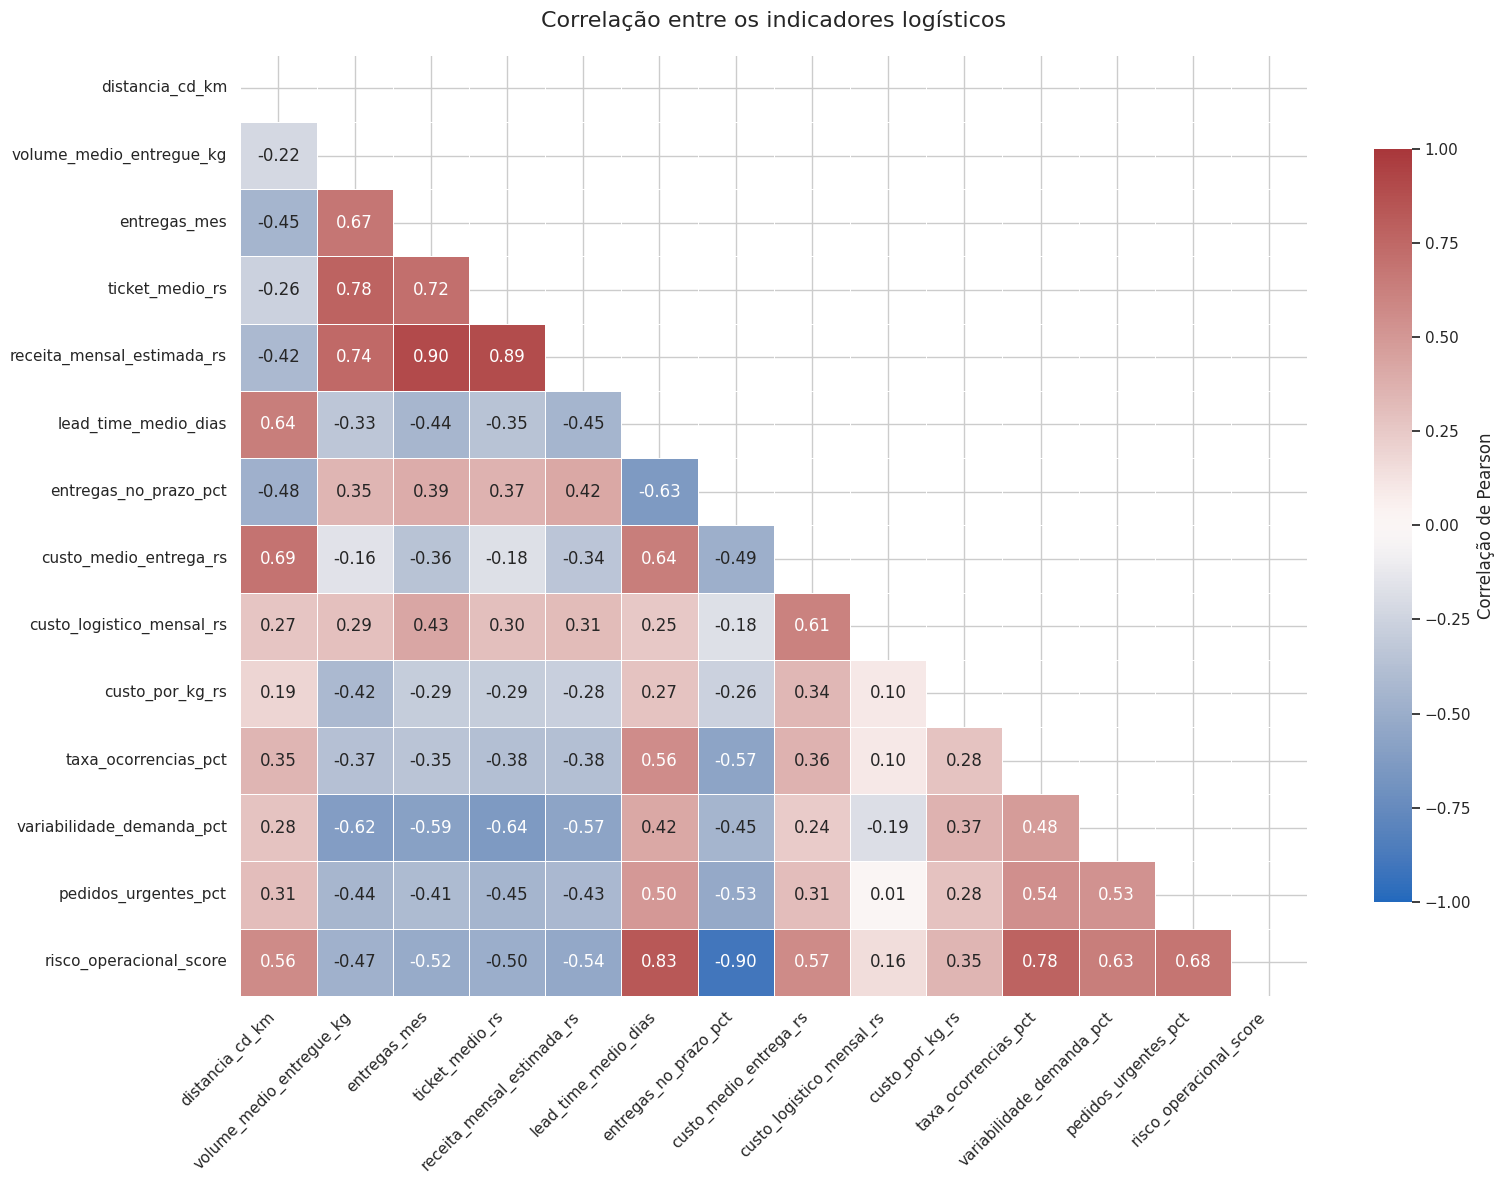

In [13]:
# Calcula a correlação entre as variáveis numéricas operacionais.
matriz_correlacao = clientes_df[colunas_numericas_eda].corr()

# Oculta a parte superior repetida da matriz.
mascara_superior = np.triu(
    np.ones_like(matriz_correlacao, dtype=bool)
)

# Cria o mapa de calor das correlações.
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_correlacao,
    mask=mascara_superior,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlação de Pearson",
    },
)

# Ajusta os textos e o layout.
plt.title(
    "Correlação entre os indicadores logísticos",
    fontsize=16,
    pad=20,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Leitura da matriz de correlação

- A receita mensal possui correlação forte com o número de entregas (0,90), o ticket médio (0,89) e o volume entregue (0,74), refletindo a dimensão econômica e operacional dos clientes.
- O risco operacional apresenta forte relação negativa com as entregas no prazo (-0,90) e relações positivas com lead time (0,83), ocorrências (0,78), pedidos urgentes (0,68) e variabilidade da demanda (0,63).
- A distância possui correlação positiva com o custo médio por entrega (0,69) e com o lead time (0,64), sugerindo maior pressão logística em operações mais distantes.
- Lead time e entregas no prazo apresentam correlação negativa (-0,63), indicando que tempos maiores estão associados a menor nível de serviço neste cenário sintético.

Algumas variáveis carregam informações semelhantes. Ao utilizá-las conjuntamente no K-Means, determinadas dimensões podem ganhar maior peso. As variáveis recomendadas serão mantidas, mas essa dependência será considerada na interpretação e nas limitações do projeto.

Correlação não representa causalidade, especialmente em uma base sintética.